(a) First‑Order Partial Derivatives of below

G(x,y) = (1 / (2 * sp.pi * sigma**2)) * sp.exp(-(x**2 + y**2) / (2 * sigma**2))

In [1]:
import sympy as sp

# Define variables
x, y, sigma = sp.symbols('x y sigma', positive=True)

# Define 2D Gaussian function
G = (1 / (2 * sp.pi * sigma**2)) * sp.exp(-(x**2 + y**2) / (2 * sigma**2))

# Compute partial derivatives
dG_dx = sp.diff(G, x)
dG_dy = sp.diff(G, y)

print("dG_dx =", sp.simplify(dG_dx))
print("dG_dy =", sp.simplify(dG_dy))


dG_dx = -x*exp(-(x**2 + y**2)/(2*sigma**2))/(2*pi*sigma**4)
dG_dy = -y*exp(-(x**2 + y**2)/(2*sigma**2))/(2*pi*sigma**4)


after simplify we get 
dG_dx = (-x/sigma**2)*G(x,y)
dG_dy = (-y/sigma**2)*G(x,y)

(b) Compute Normalized 5×5 Kernels (sigma = 2)

In [3]:
import numpy as np

def gaussian_derivative_kernel(size=5, sigma=2, axis='x'):
    """Compute derivative of Gaussian kernel in x or y direction."""
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    G = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    G = G / (2 * np.pi * sigma**2)  # normalize Gaussian

    if axis == 'x':
        kernel = -xx / (sigma**2) * G
    else:
        kernel = -yy / (sigma**2) * G

    # Normalize kernel to sum of absolute values = 1
    kernel /= np.sum(np.abs(kernel))
    return kernel

kx = gaussian_derivative_kernel(5, 2, 'x')
ky = gaussian_derivative_kernel(5, 2, 'y')

print("5x5 Derivative of Gaussian Kernel (x-direction):\n", kx)
print("5x5 Derivative of Gaussian Kernel (y-direction):\n", ky)


5x5 Derivative of Gaussian Kernel (x-direction):
 [[ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131 -0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]]
5x5 Derivative of Gaussian Kernel (y-direction):
 [[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]


(c) Visualize 51×51 Kernels as 3D surface

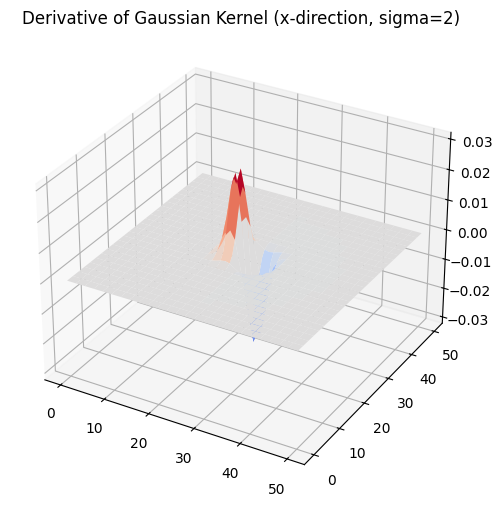

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

kx_51 = gaussian_derivative_kernel(51, 2, 'x')

X, Y = np.meshgrid(np.arange(51), np.arange(51))
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kx_51, cmap='coolwarm')
ax.set_title("Derivative of Gaussian Kernel (x-direction, sigma=2)")
plt.show()


(d) Apply Kernels to Image (Gradients)

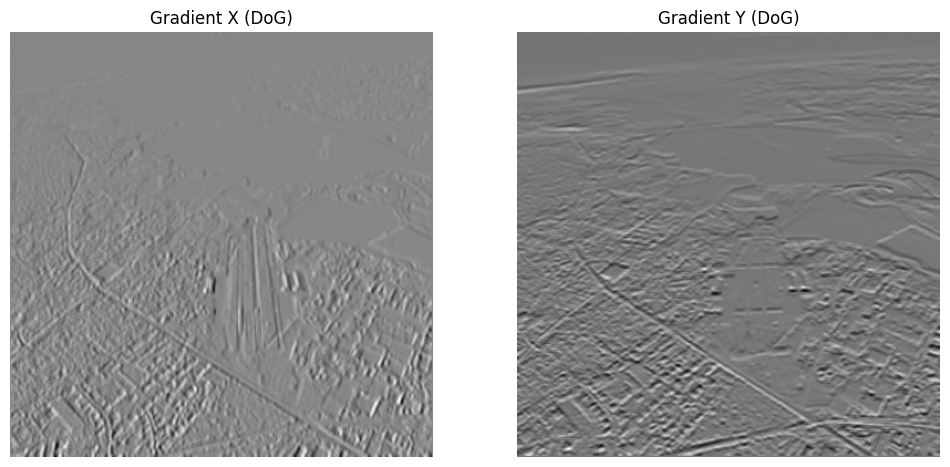

In [8]:
import cv2 as cv

#load the image in grayscale mode
f = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/runway.png', cv.IMREAD_REDUCED_GRAYSCALE_2)
assert f is not None


# Apply convolution with derivative kernels
grad_x = cv.filter2D(f, cv.CV_64F, kx)
grad_y = cv.filter2D(f, cv.CV_64F, ky)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Gradient X (DoG)")
plt.imshow(grad_x, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Gradient Y (DoG)")
plt.imshow(grad_y, cmap='gray')
plt.axis("off")
plt.show()


(e) Compare with OpenCV Sobel

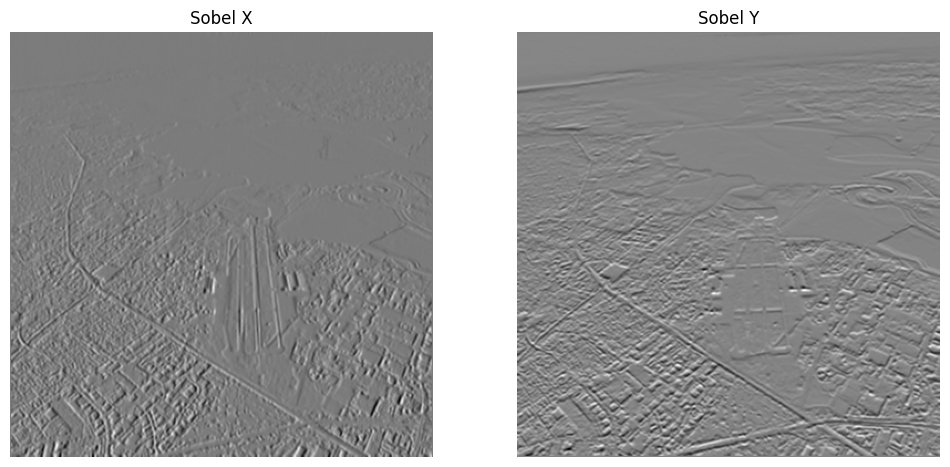

In [10]:
sobel_x = cv.Sobel(f, cv.CV_64F, 1, 0, ksize=5)
sobel_y = cv.Sobel(f, cv.CV_64F, 0, 1, ksize=5)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Sobel X")
plt.imshow(sobel_x, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Sobel Y")
plt.imshow(sobel_y, cmap='gray')
plt.axis("off")
plt.show()


Sobel outputs edges seems to be sharper than Derivative of Gaussian (DoG) output.
Derivative of Gaussian (DoG) : This smooths the image first (Gaussian blur) and then computes the derivative. The smoothing reduces noise but also softens edges, so the gradients look smoother and less sharp.
Sobel : Combines smoothing and derivative in one operator. But can be more sensitive to noise compared to DoG.